## Import Library

In [24]:
%pip install missingno
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# visualization tools
import matplotlib.pyplot as plt
import seaborn as sns
# import pandas_profiling as pp
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)

import warnings
warnings.filterwarnings("ignore")

## Upload Dataset

In [7]:
try:
    df_tj = pd.read_csv('df_tj_preprocessed.csv')
    print("File berhasil dimuat.")
except FileNotFoundError:
    print("Error: File tidak ditemukan. Pastikan file berada di direktori yang sama.")

File berhasil dimuat.


In [4]:
df_tj.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,tokenized_content,lower_tokenized_content,removed_stopwords_content,lemmatized_content,stemmed_content,cleaned_content,cleaned_content_no_common
0,bde4ccb0-d440-461c-8a10-ee2d6ee0e815,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,👍,5,0,2.9.0,2025-10-05 15:49:49,NaN,NaN,2.9.0,['👍'],['👍'],['👍'],[''],[''],NaN,NaN
1,05b3aa4e-2214-4c5c-b193-d3d824f88c8d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi lemot gk guna.gk mau respon pas login...,1,0,2.9.0,2025-10-04 19:49:12,NaN,NaN,2.9.0,"['aplikasi', 'lemot', 'gk', 'guna.gk', 'mau', ...","['aplikasi', 'lemot', 'gk', 'guna.gk', 'mau', ...","['aplikasi', 'lemot', 'guna.gk', 'respon', 'pa...","['aplikasi', 'lot', 'guna gk', 'respon', 'pas'...","['aplikasi', 'lot', 'guna gk', 'respon', 'pa',...",aplikasi lot guna gk respon pa login guna,aplikasi lot gk respon pa login
2,19bd7606-fa19-4908-91f4-51b8426b3434,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baru coba,5,0,NaN,2025-10-04 14:06:36,NaN,NaN,NaN,"['baru', 'coba']","['baru', 'coba']",['coba'],['coba'],['coba'],coba,coba
3,dcbb0018-4af8-449d-80bf-c89767ec1152,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"aplikasi nya mempermudah banget, tetapi kalo o...",4,0,2.9.0,2025-10-04 13:33:11,NaN,NaN,2.9.0,"['aplikasi', 'nya', 'mempermudah', 'banget', '...","['aplikasi', 'nya', 'mempermudah', 'banget', '...","['aplikasi', 'mempermudah', ',', 'kalo', 'oper...","['aplikasi', 'mudah', '', 'kalo', 'operasional...","['aplikasi', 'mudah', '', 'kalo', 'operasion',...",aplikasi mudah kalo operasion jalan tol bata ...,aplikasi mudah kalo operasion jalan tol bata 2...
4,a63a99d1-bc93-42b1-bd1a-d20a8170e576,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat baik,5,0,NaN,2025-10-04 09:54:37,NaN,NaN,NaN,"['sangat', 'baik']","['sangat', 'baik']",[],[],[],NaN,NaN


In [8]:
df_tj.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3016 entries, 0 to 3015
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   reviewId                   3016 non-null   object
 1   userName                   3016 non-null   object
 2   userImage                  3016 non-null   object
 3   content                    3016 non-null   object
 4   score                      3016 non-null   int64 
 5   thumbsUpCount              3016 non-null   int64 
 6   reviewCreatedVersion       2534 non-null   object
 7   at                         3016 non-null   object
 8   replyContent               4 non-null      object
 9   repliedAt                  4 non-null      object
 10  appVersion                 2534 non-null   object
 11  tokenized_content          3016 non-null   object
 12  lower_tokenized_content    3016 non-null   object
 13  removed_stopwords_content  3016 non-null   object
 14  lemmatiz

In [9]:
df_tj.isnull().sum()

reviewId                        0
userName                        0
userImage                       0
content                         0
score                           0
thumbsUpCount                   0
reviewCreatedVersion          482
at                              0
replyContent                 3012
repliedAt                    3012
appVersion                    482
tokenized_content               0
lower_tokenized_content         0
removed_stopwords_content       0
lemmatized_content              0
stemmed_content                 0
cleaned_content                66
cleaned_content_no_common      82
dtype: int64

In [17]:
from textblob import TextBlob
# Handle None values in 'content' column by replacing them with empty strings
df_tj['sentiment_polarity'] = df_tj['stemmed_content'].astype(str).apply(lambda x: TextBlob(x).polarity)
df_tj['sentiment_subjective'] = df_tj['stemmed_content'].astype(str).apply(lambda x: TextBlob(x).subjectivity)


In [18]:
df_tj['sentiment_rating'] = df_tj['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [19]:
df_tj.loc[:,["cleaned_content_no_common","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,cleaned_content_no_common,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,NaN,5,0.0,0.0,Positive
1,aplikasi lot gk respon pa login,1,0.0,0.0,Negative
2,coba,5,0.0,0.0,Positive
3,aplikasi mudah kalo operasion jalan tol bata 2...,4,0.0,0.0,Positive
4,NaN,5,0.0,0.0,Positive
...,...,...,...,...,...
3011,mantap,5,0.0,0.0,Positive
3012,crash pilih profil,5,0.0,0.0,Positive
3013,aplikasi kocag becu bikin aplikasi masuk kerja...,1,-0.4,0.4,Negative
3014,aplikasi server eror load cari rute susah posi...,1,0.0,0.0,Negative


Note: you may need to restart the kernel to use updated packages.


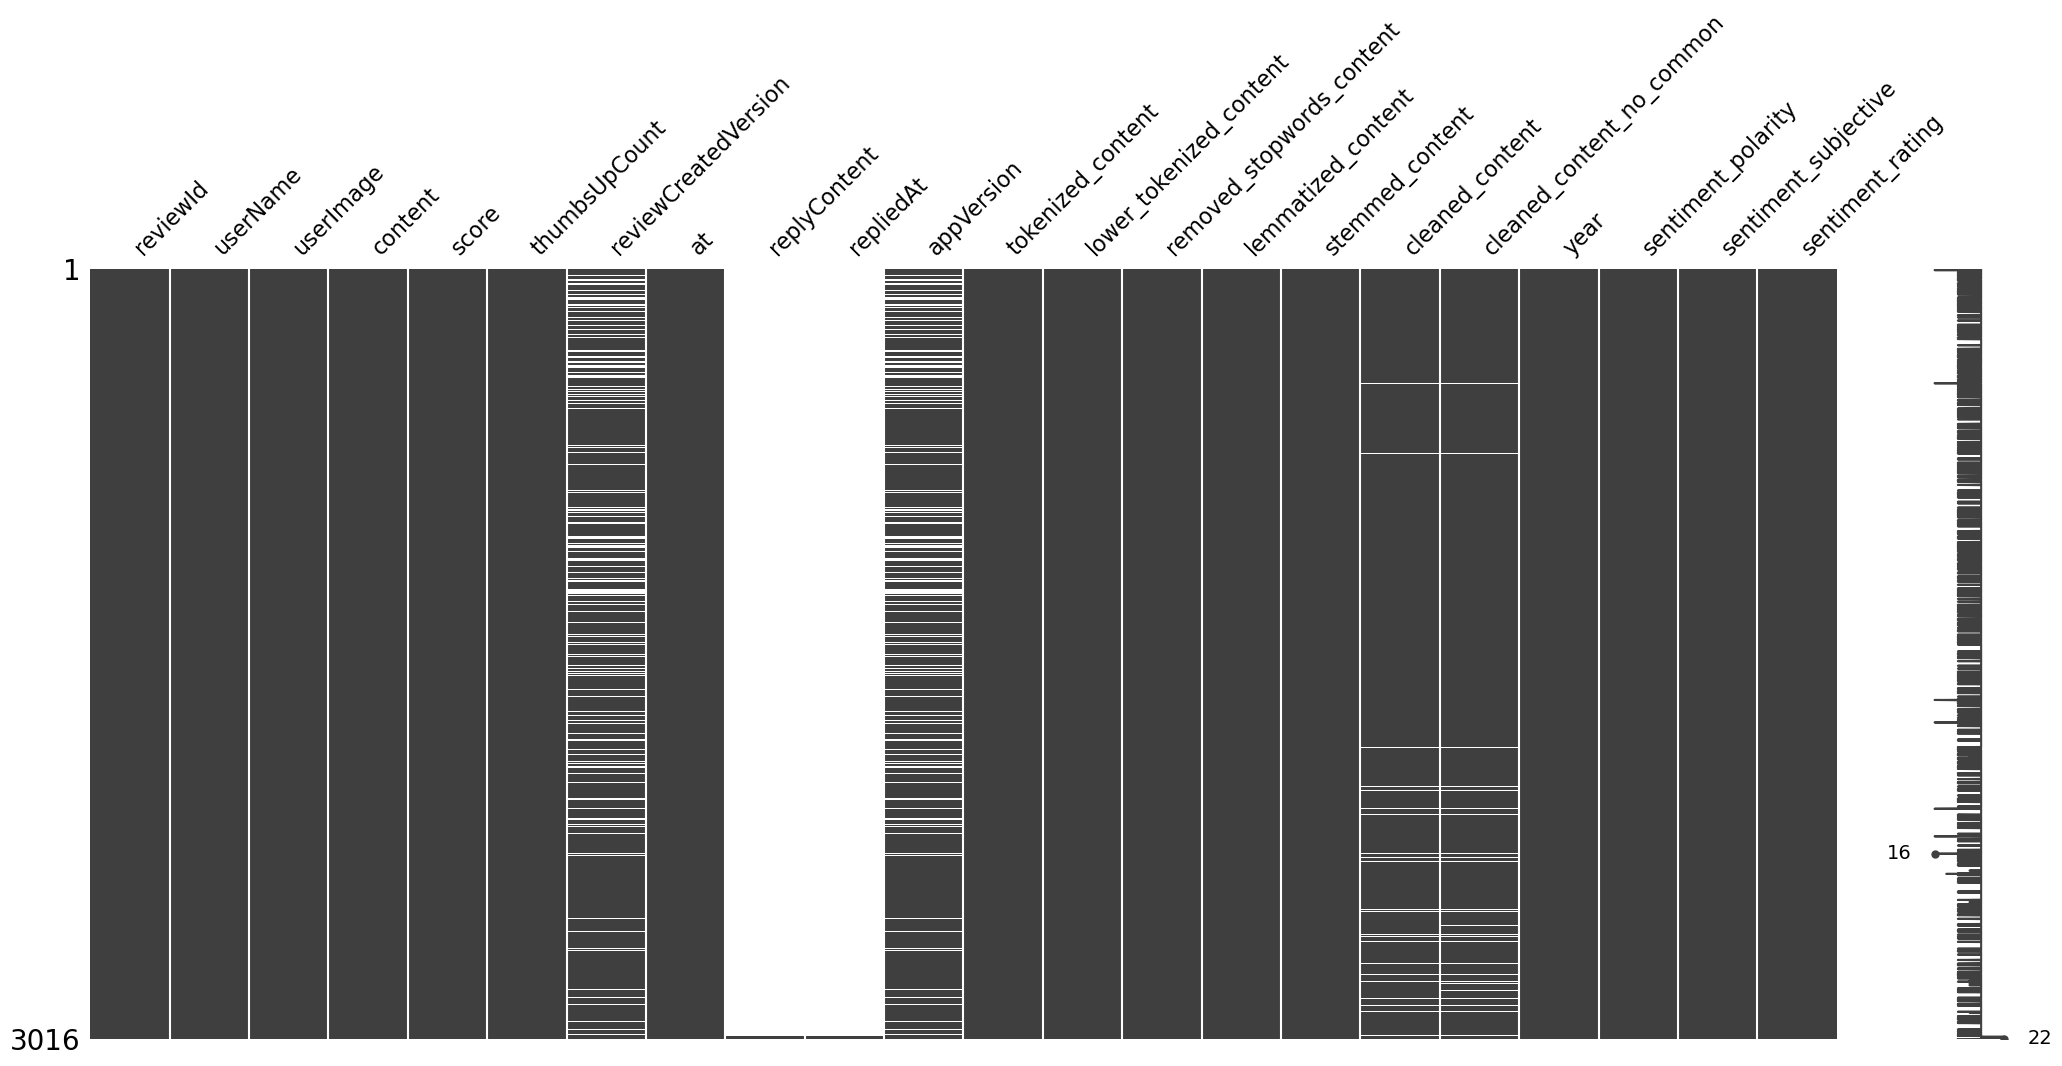

In [20]:
import missingno as msno
msno.matrix(df_tj)
plt.show()

In [21]:
# Assuming 'df_tj' is your DataFrame
df_tj['at'] = pd.to_datetime(df_tj['at'])
df_tj['year'] = df_tj['at'].dt.year

# Select only the desired columns
df_selected = df_tj[['content', 'cleaned_content_no_common', 'score', 'sentiment_rating', 'at', 'year']]

# Display the selected columns
df_selected

,content,cleaned_content_no_common,score,sentiment_rating,at,year
0,👍,NaN,5,Positive,2025-10-05 15:49:49,2025
1,aplikasi lemot gk guna.gk mau respon pas login...,aplikasi lot gk respon pa login,1,Negative,2025-10-04 19:49:12,2025
2,baru coba,coba,5,Positive,2025-10-04 14:06:36,2025
3,"aplikasi nya mempermudah banget, tetapi kalo o...",aplikasi mudah kalo operasion jalan tol bata 2...,4,Positive,2025-10-04 13:33:11,2025
4,sangat baik,NaN,5,Positive,2025-10-04 09:54:37,2025
...,...,...,...,...,...,...
3011,Mantaps,mantap,5,Positive,2024-05-16 18:10:02,2024
3012,Sudah enggak crash kalau pilih profil,crash pilih profil,5,Positive,2024-05-16 11:52:59,2024
3013,"Aplikasi kocag, gk becus bikin aplikasi, masuk...",aplikasi kocag becu bikin aplikasi masuk kerja...,1,Negative,2024-05-12 16:42:40,2024
3014,"Aplikasi gak jelas, server eror, loading lama,...",aplikasi server eror load cari rute susah posi...,1,Negative,2024-05-11 20:43:39,2024


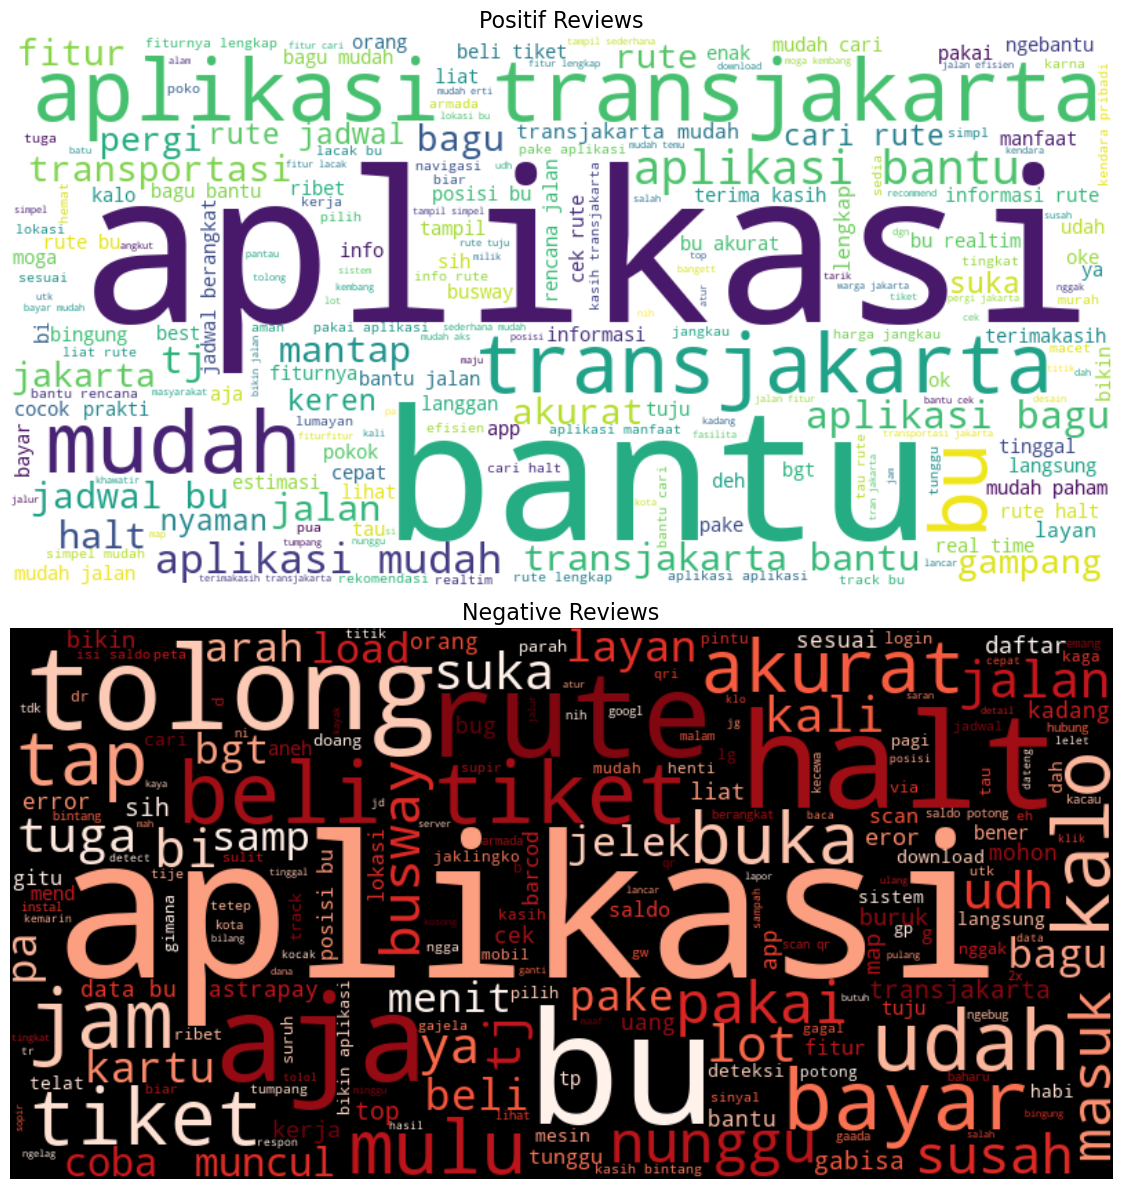

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gabungkan semua cleaned_content_no_common untuk masing-masing sentimen
positive_reviews = ' '.join(df_selected[df_selected['sentiment_rating'] == 'Positive']['cleaned_content_no_common'].dropna().astype(str))
negative_reviews = ' '.join(df_selected[df_selected['sentiment_rating'] == 'Negative']['cleaned_content_no_common'].dropna().astype(str))

# Buat Word Cloud untuk ulasan POSITIF
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(positive_reviews)

# Buat Word Cloud untuk ulasan NEGATIF
wordcloud_negative = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_reviews)

# Tampilkan Word Clouds
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

axes[0].imshow(wordcloud_positive, interpolation='bilinear')
axes[0].set_title('Positif Reviews', fontsize=16)
axes[0].axis('off')

axes[1].imshow(wordcloud_negative, interpolation='bilinear')
axes[1].set_title('Negative Reviews', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [27]:
df_tj.to_csv('df_tj_sentiment_analysis.csv', index=False)